In [1]:
import time
start_time = time.time()

In [2]:
#parameters
current_year = None
current_week = None
client_name = None

In [3]:
if not (current_year or current_week or client_name):
    current_year = 2025
    current_week = 18
    client_name = "notebook"


In [4]:
start_year = 2010

current_year_week = f"{current_year}_{current_week}"

# Imports

In [5]:
import os
if os.environ.get("LOCALHOST") == "True":
    os.chdir('/Users/willboyd/Desktop/Repos/sports-models')

environment = os.environ.get("ENVIRONMENT")

In [6]:
#turns off any warnings
import warnings
warnings.filterwarnings('ignore')

#various modules
import nfl_data_py as nfl
#from sportsreference.nfl.boxscore import Boxscores, Boxscore

import os
import sys


import pandas as pd
from bs4 import BeautifulSoup
import matplotlib.pyplot as plt
import matplotlib.ticker as plticker
import pickle
import json
import seaborn as sns
import numpy as np
import xgboost as xgb
import math
import datetime
import pytz

from lightgbm import LGBMRegressor
from lightgbm import LGBMClassifier
from sklearn.model_selection import cross_val_predict

from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import GridSearchCV
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split

from src.sports.football.nfl.utils.expected_points_functions import get_result_stats, calculate_wins
from src.utils.data_models.picks_response import PickResponse
from src.utils.db.sports_models_db import (
    get_nfl_picks,
    get_nfl_results,
    insert_nfl_pick_update,
    upsert_nfl_picks,
    upsert_nfl_results,
)


In [7]:
def run_imports(years, true_years):
    pbp = nfl.import_pbp_data(years, downcast=True, cache=False, alt_path=None)
    weekly = nfl.import_weekly_data(range(start_year - 1, current_year), downcast=True)
    season = pd.DataFrame()# nfl.import_seasonal_data(years, s_type='REG')
    injury =  pd.DataFrame()# nfl.import_injuries(years)
    full_schedule = nfl.import_schedules(true_years)
    teams = nfl.import_team_desc()
    
    return pbp, weekly, season, injury, full_schedule, teams



# First attempt
years = range(start_year - 1, current_year + 1)
true_years = range(start_year, current_year + 1)

pbp = nfl.import_pbp_data(years, downcast=True, cache=False, alt_path=None)
weekly = nfl.import_weekly_data(range(start_year - 1, current_year), downcast=True) # a week less
#season = pd.DataFrame() # nfl.import_seasonal_data(years, s_type='REG')
#injury =  pd.DataFrame() # nfl.import_injuries(years)
full_schedule = nfl.import_schedules(true_years)
teams = nfl.import_team_desc()

# try:
#     pbp, weekly, season, injury, full_schedule, teams = run_imports(years, true_years)

# except Exception as e:
#     print(f"Initial attempt failed: {e}")
#     print("Retrying a year back...")

#     years = range(start_year - 1, current_year)
#     true_years = range(start_year, current_year + 1)

#     pbp, weekly, season, injury, full_schedule, teams = run_imports(years, true_years)

2009 done.
2010 done.
2011 done.
2012 done.
2013 done.
2014 done.
2015 done.
2016 done.
2017 done.
2018 done.
2019 done.
2020 done.
2021 done.
2022 done.
2023 done.
2024 done.
2025 done.
Downcasting floats.
Downcasting floats.


In [8]:
weekly_2025 = pd.read_csv("https://github.com/nflverse/nflverse-data/releases/download/stats_player/stats_player_week_2025.csv")

#new column: old_column
weekly_2025 = weekly_2025.rename(columns={"team": "recent_team", 
                                          "passing_interceptions": "interceptions",
                                          "sacks_suffered": "sacks",
                                          "sack_yards_lost": "sack_yards"})

weekly = weekly.drop(columns=["dakota"])

# Concatenate weekly with weekly_2025 vertically (like SQL UNION ALL)
weekly = pd.concat([weekly, weekly_2025], axis=0, ignore_index=True)

# Data transformation and feature engineering

In [9]:
pbp['home_team'] = pbp['home_team'].replace({'OAK': 'LV', 'SD': 'LAC', 'STL': 'LA'})
pbp['away_team'] = pbp['away_team'].replace({'OAK': 'LV', 'SD': 'LAC', 'STL': 'LA'})
pbp['posteam'] = pbp['posteam'].replace({'OAK': 'LV', 'SD': 'LAC', 'STL': 'LA'})
pbp['defteam'] = pbp['defteam'].replace({'OAK': 'LV', 'SD': 'LAC', 'STL': 'LA'})

full_schedule['home_team'] = full_schedule['home_team'].replace({'OAK': 'LV', 'SD': 'LAC', 'STL': 'LA'})
full_schedule['away_team'] = full_schedule['away_team'].replace({'OAK': 'LV', 'SD': 'LAC', 'STL': 'LA'})

In [10]:
pbp['rz'] = np.where(((pbp['defteam'] == pbp['side_of_field']) & ((pbp['yardline_100'] <= 20) | (pbp['yardline_100'] >= 80))), 1, 0)

In [11]:
schedule_columns = ['game_id', 'season', 'week', 'home_team','away_team','weekday', 'home_qb_id', 'away_qb_id', 'home_moneyline', 'away_moneyline','spread_line',
                 'home_spread_odds', 'away_spread_odds','total_line',  'over_odds', 'roof', 'away_rest', 'home_rest', 'stadium_id', 'div_game', 'gametime', 'gameday']
schedule = full_schedule[schedule_columns].dropna(subset = 'total_line')

In [12]:
def get_implied_totals(row):
    home_points = (row['total_line'] / 2) + (row['spread_line'] / 2)
    away_points = (row['total_line'] / 2) - (row['spread_line'] / 2)
    return pd.Series([home_points, away_points])


In [13]:
schedule[['implied_points_home', 'implied_points_away']] = schedule.apply(get_implied_totals, axis=1)

## Advanced stats

In [14]:
melted_schedule_teams = pd.melt(schedule, id_vars=['season', 'week'], value_vars=['home_team', 'away_team'], value_name='team').drop('variable', axis=1).reset_index(drop=True)[['season', 'week', 'team']]
melted_schedule_qbs = pd.melt(schedule, id_vars=['season', 'week'], value_vars=['home_qb_id', 'away_qb_id'], value_name='qb_id').drop('variable', axis=1).reset_index(drop=True)[['season', 'week', 'qb_id']]
melted_schedule = pd.concat([melted_schedule_teams, melted_schedule_qbs['qb_id']], axis=1)

### QBR

In [15]:
def nfl_passer_rating(cmpls, yds, tds, ints):
     """ Defines a function which handles passer rating calculation for the NFL."""
     def _min_max(x, xmin, xmax):

         # Check if x is less than the minimum. If so, return the minimum.
         if x < xmin:
             return xmin
         
         # Check if x is greater than the maximum. If so, return the maximum.
         elif x > xmax:
             return xmax
         
         # Otherwise, just return x. And weep for the future.
         else:
             return x
             
     # Step 0: Make sure these are floats, dammit.
     cmpls = cmpls + 0.0
     yds = yds + 0.0
     tds = tds + 0.0
     ints = ints + 0.0
     
     # Step 1: The completion percentage.         
     step_1 = cmpls - 0.3
     step_1 = step_1 * 5
     step_1 = _min_max(step_1, 0, 2.375)
     
     # Step 2: The yards per attempt.
     step_2 = yds - 3
     step_2 = step_2 * 0.25
     step_2 = _min_max(step_2, 0, 2.375)
     
     # Step 3: Touchdown percentage.
     step_3 = tds * 20
     step_3 = _min_max(step_3, 0, 2.375)
     
     # Step 4: Interception percentage.
     step_4 = ints * 25
     step_4 = 2.375 - step_4
     step_4 = _min_max(step_4, 0, 2.375)
     
     # Step 5: Compute the rating based on the sum of steps 1-4.
     rating = step_1 + step_2 + step_3 + step_4 + 0.0
     rating = rating / 6
     rating = rating * 100
     
     # Step 6: Return the rating, formatted to 1 decimal place, as a Decimal.
     return rating

def calculate_qbr(att, comp, yds, td, ints):

    #replace with college qbr?
    if att == 0:
        return 0

    a = ((comp/att) - 0.3) * 5
    b = ((yds/att) - 3) * 0.25
    c = (td/att) * 20
    d = 2.375 - ((ints/att) * 25)

    for i in [a, b, c, d]:
        if i < 0:
            i = 0
        elif i > 2.375:
            i = 2.375

    passer_rating = ((a + b + c + d) / 6) * 100

    return passer_rating

In [16]:
qbs_weekly = weekly[weekly['position_group']=='QB']
qbs_weekly['passer_rating'] = qbs_weekly.apply(lambda row: nfl_passer_rating(row['completions'], row['passing_yards'], row['passing_tds'], row['interceptions']), axis=1)
qbs_weekly['qbr'] = qbs_weekly.apply(lambda row: calculate_qbr(row['attempts'], row['completions'], row['passing_yards'], row['passing_tds'], row['interceptions']), axis=1)

In [17]:
starting_qbs =  pd.merge(melted_schedule.rename(columns={"qb_id": "player_id"}), qbs_weekly, on=['season', 'week', 'player_id'], how='left').sort_values(by=['player_id', 'season', 'week']).reset_index(drop=True)
first_game = starting_qbs.groupby('player_id').first()[['qbr', 'passer_rating']].mean()

starting_qbs['passer_rating_shifted'] = starting_qbs.groupby('player_id')['passer_rating'].shift()
starting_qbs['qbr_shifted'] = starting_qbs.groupby('player_id')['qbr'].shift()
starting_qbs['player_name'] = starting_qbs.groupby('player_id')['player_name'].shift()

#starting_qbs['passer_rating_shifted'] = starting_qbs['passer_rating_shifted'].fillna(value = first_game['passer_rating'])
starting_qbs['qbr_shifted'] = starting_qbs['qbr_shifted'].fillna(value = first_game['qbr'])

starting_qbs['ewma_passer_rating'] = starting_qbs.groupby('player_id')['passer_rating_shifted'].transform(lambda x: x.ewm(min_periods=1, span=10).mean())
starting_qbs['ewma_qbr'] = starting_qbs.groupby('player_id')['qbr_shifted'].transform(lambda x: x.ewm(min_periods=1, span=10).mean())

starting_qbs[(starting_qbs['season'] == 2023) & (starting_qbs['week'] == current_week)][['team', 'player_name', 'passer_rating_shifted', 'qbr_shifted', 'ewma_passer_rating', 'ewma_qbr']].head()

,team,player_name,passer_rating_shifted,qbr_shifted,ewma_passer_rating,ewma_qbr
3648,KC,B.Gabbert,158.333333,121.354167,124.927708,77.599915
4001,NYG,T.Taylor,118.750000,87.347561,118.800862,77.803706
4916,TEN,R.Tannehill,118.750000,84.134615,110.603114,78.340752
5053,SEA,G.Smith,158.333333,106.881313,133.289237,93.544086
5331,NO,D.Carr,158.333333,111.067708,132.362376,103.581271


### EPA per Play

In [18]:
def dynamic_window_ewma(x):
    """
    Calculate rolling exponentially weighted EPA with a dynamic window size
    """
    values = np.zeros(len(x))
    for i, (_, row) in enumerate(x.iterrows()):
        epa = x.epa_shifted[:i+1]
        if row.week > 10:
            values[i] = epa.ewm(min_periods=1, span=row.week).mean().values[-1]
        else:
            values[i] = epa.ewm(min_periods=1, span=10).mean().values[-1]
            
    return pd.Series(values, index=x.index)

# seperate EPA in to rushing offense, rushing defense, passing offense, passing defense for each team
rushing_offense_epa = pbp.loc[pbp['rush_attempt'] == 1, :].groupby(['posteam', 'season', 'week'], as_index=False)['epa'].mean()
rushing_defense_epa = pbp.loc[pbp['rush_attempt'] == 1, :].groupby(['defteam', 'season', 'week'], as_index=False)['epa'].mean()
passing_offense_epa = pbp.loc[pbp['pass_attempt'] == 1, :].groupby(['posteam', 'season', 'week'], as_index=False)['epa'].mean()
passing_defense_epa = pbp.loc[pbp['pass_attempt'] == 1, :].groupby(['defteam', 'season', 'week'], as_index=False)['epa'].mean()

rushing_offense_epa =  pd.merge(melted_schedule_teams.rename(columns={"team": "posteam"}), rushing_offense_epa, on=['season', 'week', 'posteam'], how='outer').sort_values(by=['posteam', 'season', 'week']).reset_index(drop=True)
rushing_defense_epa =  pd.merge(melted_schedule_teams.rename(columns={"team": "defteam"}), rushing_defense_epa, on=['season', 'week', 'defteam'], how='outer').sort_values(by=['defteam', 'season', 'week']).reset_index(drop=True)
passing_offense_epa =  pd.merge(melted_schedule_teams.rename(columns={"team": "posteam"}), passing_offense_epa, on=['season', 'week', 'posteam'], how='outer').sort_values(by=['posteam', 'season', 'week']).reset_index(drop=True)
passing_defense_epa =  pd.merge(melted_schedule_teams.rename(columns={"team": "defteam"}), passing_defense_epa, on=['season', 'week', 'defteam'], how='outer').sort_values(by=['defteam', 'season', 'week']).reset_index(drop=True)

# # lag EPA one period back
rushing_offense_epa['epa_shifted'] = rushing_offense_epa.groupby('posteam')['epa'].shift()
rushing_defense_epa['epa_shifted'] = rushing_defense_epa.groupby('defteam')['epa'].shift()
passing_offense_epa['epa_shifted'] = passing_offense_epa.groupby('posteam')['epa'].shift()
passing_defense_epa['epa_shifted'] = passing_defense_epa.groupby('defteam')['epa'].shift()

# In each case, calculate EWMA with a static window and dynamic window and assign it as a column 
rushing_offense_epa['ewma'] = rushing_offense_epa.groupby('posteam')['epa_shifted'].transform(lambda x: x.ewm(min_periods=1, span=10).mean())
rushing_offense_epa['ewma_dynamic_window'] = rushing_offense_epa.groupby('posteam').apply(dynamic_window_ewma).values
rushing_defense_epa['ewma'] = rushing_defense_epa.groupby('defteam')['epa_shifted'].transform(lambda x: x.ewm(min_periods=1, span=10).mean())
rushing_defense_epa['ewma_dynamic_window'] = rushing_defense_epa.groupby('defteam').apply(dynamic_window_ewma).values
passing_offense_epa['ewma'] = passing_offense_epa.groupby('posteam')['epa_shifted'].transform(lambda x: x.ewm(min_periods=1, span=10).mean())
passing_offense_epa['ewma_dynamic_window'] = passing_offense_epa.groupby('posteam').apply(dynamic_window_ewma).values
passing_defense_epa['ewma'] = passing_defense_epa.groupby('defteam')['epa_shifted'].transform(lambda x: x.ewm(min_periods=1, span=10).mean())
passing_defense_epa['ewma_dynamic_window'] = passing_defense_epa.groupby('defteam').apply(dynamic_window_ewma).values

#Merge all the data together
offense_epa = rushing_offense_epa.merge(passing_offense_epa, on=['posteam', 'season', 'week'], suffixes=('_rushing', '_passing')).rename(columns={'posteam': 'team'})
defense_epa = rushing_defense_epa.merge(passing_defense_epa, on=['defteam', 'season', 'week'], suffixes=('_rushing', '_passing')).rename(columns={'defteam': 'team'})
epa = offense_epa.merge(defense_epa, on=['team', 'season', 'week'], suffixes=('_offense', '_defense'))

#remove the first season of data
epa = epa.loc[epa['season'] != epa['season'].unique()[0], :]

epa = epa.reset_index(drop=True)

epa.head()

,season,week,team,epa_rushing_offense,epa_shifted_rushing_offense,ewma_rushing_offense,ewma_dynamic_window_rushing_offense,epa_passing_offense,epa_shifted_passing_offense,ewma_passing_offense,ewma_dynamic_window_passing_offense,epa_rushing_defense,epa_shifted_rushing_defense,ewma_rushing_defense,ewma_dynamic_window_rushing_defense,epa_passing_defense,epa_shifted_passing_defense,ewma_passing_defense,ewma_dynamic_window_passing_defense
0,2010,1,ARI,-0.509499,0.042909,-0.040601,-0.040601,0.065670,-0.238080,0.011907,0.011907,-0.102009,0.100856,0.010302,0.010302,-0.242055,0.444903,0.049067,0.049067
1,2010,2,ARI,0.240758,-0.509499,-0.127780,-0.127780,-0.517255,0.065670,0.021902,0.021902,-0.012757,-0.102009,-0.010580,-0.010580,0.397588,-0.242055,-0.005060,-0.005060
2,2010,3,ARI,-0.082519,0.240758,-0.059540,-0.059540,-0.222157,-0.517255,-0.077930,-0.077930,-0.153081,-0.012757,-0.010983,-0.010983,0.009566,0.397588,0.069496,0.069496
3,2010,4,ARI,-0.056444,-0.082519,-0.063781,-0.063781,-0.658215,-0.222157,-0.104547,-0.104547,-0.153543,-0.153081,-0.037207,-0.037207,0.736856,0.009566,0.058436,0.058436
4,2010,5,ARI,-0.408016,-0.056444,-0.062431,-0.062431,-0.028002,-0.658215,-0.206447,-0.206447,-0.325153,-0.153543,-0.058618,-0.058618,-0.097027,0.736856,0.183296,0.183296


### Success Rates

In [19]:
pbp['custom_success'] = ((pbp['down'] == 1) & (pbp['yards_gained'] >= 0.4 * pbp['ydstogo'])) | \
                        ((pbp['down'] == 2) & (pbp['yards_gained'] >= 0.6 * pbp['ydstogo'])) | \
                        ((pbp['down'].isin([3, 4])) & (pbp['yards_gained'] >= pbp['ydstogo']))

rushing_offense_success = pbp.loc[pbp['rush_attempt'] == 1, :].groupby(['posteam', 'season', 'week'], as_index=False)['custom_success'].mean()
rushing_defense_success = pbp.loc[pbp['rush_attempt'] == 1, :].groupby(['defteam', 'season', 'week'], as_index=False)['custom_success'].mean()
passing_offense_success = pbp.loc[pbp['pass_attempt'] == 1, :].groupby(['posteam', 'season', 'week'], as_index=False)['custom_success'].mean()
passing_defense_success = pbp.loc[pbp['pass_attempt'] == 1, :].groupby(['defteam', 'season', 'week'], as_index=False)['custom_success'].mean()

rushing_offense_success =  pd.merge(melted_schedule_teams.rename(columns={"team": "posteam"}), rushing_offense_success, on=['season', 'week', 'posteam'], how='outer').sort_values(by=['posteam', 'season', 'week']).reset_index(drop=True)
rushing_defense_success =  pd.merge(melted_schedule_teams.rename(columns={"team": "defteam"}), rushing_defense_success, on=['season', 'week', 'defteam'], how='outer').sort_values(by=['defteam', 'season', 'week']).reset_index(drop=True)
passing_offense_success =  pd.merge(melted_schedule_teams.rename(columns={"team": "posteam"}), passing_offense_success, on=['season', 'week', 'posteam'], how='outer').sort_values(by=['posteam', 'season', 'week']).reset_index(drop=True)
passing_defense_success =  pd.merge(melted_schedule_teams.rename(columns={"team": "defteam"}), passing_defense_success, on=['season', 'week', 'defteam'], how='outer').sort_values(by=['defteam', 'season', 'week']).reset_index(drop=True)

rushing_offense_success['success_shifted'] = rushing_offense_success.groupby('posteam')['custom_success'].shift()
rushing_defense_success['success_shifted'] = rushing_defense_success.groupby('defteam')['custom_success'].shift()
passing_offense_success['success_shifted'] = passing_offense_success.groupby('posteam')['custom_success'].shift()
passing_defense_success['success_shifted'] = passing_defense_success.groupby('defteam')['custom_success'].shift()

rushing_offense_success['ewma_success_rate'] = rushing_offense_success.groupby('posteam')['success_shifted'].transform(lambda x: x.ewm(min_periods=1, span=10).mean())
rushing_defense_success['ewma_success_rate'] = rushing_defense_success.groupby('defteam')['success_shifted'].transform(lambda x: x.ewm(min_periods=1, span=10).mean())
passing_offense_success['ewma_success_rate'] = passing_offense_success.groupby('posteam')['success_shifted'].transform(lambda x: x.ewm(min_periods=1, span=10).mean())
passing_defense_success['ewma_success_rate'] = passing_defense_success.groupby('defteam')['success_shifted'].transform(lambda x: x.ewm(min_periods=1, span=10).mean())

offense_sucess = rushing_offense_success.merge(passing_offense_success, on=['posteam', 'season', 'week'], suffixes=('_rushing', '_passing')).rename(columns={'posteam': 'team'})
defense_sucess = rushing_defense_success.merge(passing_defense_success, on=['defteam', 'season', 'week'], suffixes=('_rushing', '_passing')).rename(columns={'defteam': 'team'})
success = offense_sucess.merge(defense_sucess, on=['team', 'season', 'week'], suffixes=('_offense', '_defense'))

#remove the first season of data
success = success.loc[success['season'] != success['season'].unique()[0], :]

success = success.reset_index(drop=True)
success.head(2)

,season,week,team,custom_success_rushing_offense,success_shifted_rushing_offense,ewma_success_rate_rushing_offense,custom_success_passing_offense,success_shifted_passing_offense,ewma_success_rate_passing_offense,custom_success_rushing_defense,success_shifted_rushing_defense,ewma_success_rate_rushing_defense,custom_success_passing_defense,success_shifted_passing_defense,ewma_success_rate_passing_defense
0,2010,1,ARI,0.476190,0.266667,0.412845,0.348837,0.567568,0.550975,0.416667,0.529412,0.481165,0.368421,0.562500,0.482872
1,2010,2,ARI,0.307692,0.476190,0.424622,0.342857,0.348837,0.513393,0.511111,0.416667,0.469174,0.515152,0.368421,0.461593


## Aggregate datasets

In [20]:
scores = pbp[['game_id','season', 'week', 'home_team', 'away_team', 'home_score', 'away_score']]\
.drop_duplicates().reset_index(drop=True)\
.assign(home_team_win = lambda x: (x.home_score > x.away_score).astype(int))

schedule_scores = schedule.merge(scores[['game_id','home_score', 'away_score']], on='game_id', how='left')

df = schedule_scores.merge(epa.rename(columns={'team': 'home_team'}), on=['home_team', 'season', 'week'], how='left')\
.merge(epa.rename(columns={'team': 'away_team'}), on=['away_team', 'season', 'week'], how='left', suffixes=('_home', '_away'))

df = df.merge(success.rename(columns={'team': 'home_team'}), on=['home_team', 'season', 'week'], how='left')\
.merge(success.rename(columns={'team': 'away_team'}), on=['away_team', 'season', 'week'], how='left', suffixes=('_home', '_away'))

df = df.merge(starting_qbs.rename(columns={'team': 'home_team'}), on=['home_team', 'season', 'week'], how='left')\
.merge(starting_qbs.rename(columns={'team': 'away_team'}), on=['away_team', 'season', 'week'], how='left', suffixes=('_home', '_away'))

df = df.rename(columns={
    'home_rest': 'rest_home',
    'away_rest': 'rest_away',
    'home_moneyline': 'moneyline_home',
    'away_moneyline': 'moneyline_away',
    'home_spread_odds': 'spread_odds_home',
    'away_spread_odds': 'spread_odds_away'
})

df['pred_team'] = 'undefined'


In [21]:
print(list(df.columns))

['game_id_x', 'season', 'week', 'home_team', 'away_team', 'weekday', 'home_qb_id', 'away_qb_id', 'moneyline_home', 'moneyline_away', 'spread_line', 'spread_odds_home', 'spread_odds_away', 'total_line', 'over_odds', 'roof', 'rest_away', 'rest_home', 'stadium_id', 'div_game', 'gametime', 'gameday', 'implied_points_home', 'implied_points_away', 'home_score', 'away_score', 'epa_rushing_offense_home', 'epa_shifted_rushing_offense_home', 'ewma_rushing_offense_home', 'ewma_dynamic_window_rushing_offense_home', 'epa_passing_offense_home', 'epa_shifted_passing_offense_home', 'ewma_passing_offense_home', 'ewma_dynamic_window_passing_offense_home', 'epa_rushing_defense_home', 'epa_shifted_rushing_defense_home', 'ewma_rushing_defense_home', 'ewma_dynamic_window_rushing_defense_home', 'epa_passing_defense_home', 'epa_shifted_passing_defense_home', 'ewma_passing_defense_home', 'ewma_dynamic_window_passing_defense_home', 'epa_rushing_offense_away', 'epa_shifted_rushing_offense_away', 'ewma_rushing_of

In [22]:
df = df[~((df['season'] == 2010) & (df['week'] == 1))]

df['spread_line'] = df['spread_line'] * -1

df['year_week'] = df['season'].astype(str) + '_' + df['week'].astype(str)
df['date_time'] = df['gameday'].astype(str) + '-' + df['gametime'].astype(str)


#df.loc[(df['season'] == 2023) & (df['week'] == 3) & (df['weekday'] == "Monday"), ['home_score', 'away_score']] = np.nan

# Define Features

In [23]:
from src.model_patterns.expected_points.types import ExpectedPointsConfig

targets = ["home_score", "away_score"]
ewma_features = [
    column for column in df.columns if "ewma" in column and "dynamic" in column
] + [column for column in df.columns if "ewma" in column and "success_rate" in column]

cat_features = ["roof", "weekday"]
betting_features = ["moneyline_home", "spread_line", "spread_odds_home", "total_line", "over_odds"]
other_features = [
    "rest_away",
    "rest_home",
    "div_game",
    "implied_points_home",
    "implied_points_away",
    "ewma_qbr_home",
    "ewma_qbr_away",
]

features = other_features + cat_features + ewma_features + betting_features
input_features = features + ["moneyline_away", "spread_odds_away"]


spread_class_features = ewma_features + betting_features + other_features + ["spread_diff"]
total_class_features = ewma_features + betting_features + other_features + ["total_diff"]

spread_class_cat_features = cat_features
total_class_cat_features = cat_features


ep_config = ExpectedPointsConfig(
    current_year=current_year,
    current_week=current_week,
    targets=targets,
    features=features,
    input_features=input_features,
    spread_class_features=spread_class_features,
    total_class_features=total_class_features,
    cat_features=cat_features,
    spread_class_cat_features=spread_class_cat_features,
    total_class_cat_features=total_class_cat_features,
    home_prediction_features=features,
    away_prediction_features=input_features,
)

# Train Model

In [24]:
from src.model_patterns.expected_points import run_expected_points

ep_run = run_expected_points(df=df, config=ep_config)

train_df = ep_run.train_df.copy()
results = ep_run.eval_results.copy()
spread_class_features = ep_config.spread_class_features
total_class_features = ep_config.total_class_features
spread_clf = ep_run.spread_clf
total_clf = ep_run.total_clf
score_model = ep_run.score_model
this_week = ep_run.this_week.copy()
plays = ep_run.plays.copy()


# Model metrics and performance

Total win percentage: 51.291079812206576
Spread win percentage: 52.60663507109005


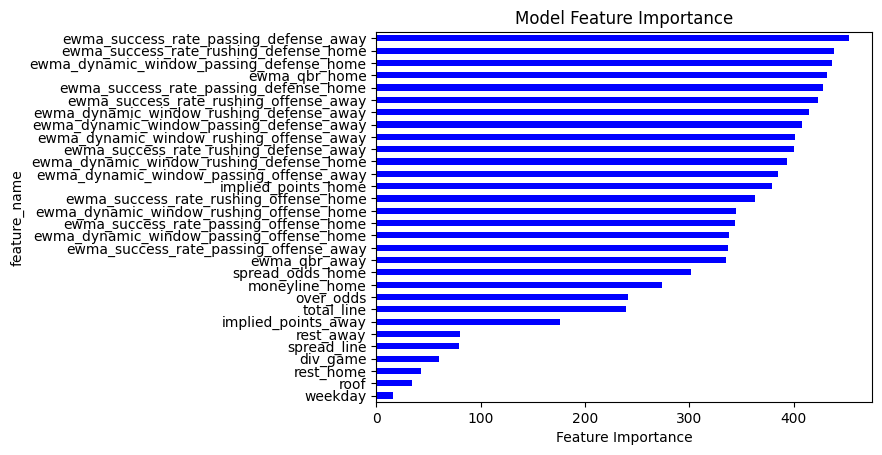

In [25]:
from src.model_patterns.expected_points.reporting import get_feature_importance_df, summarize_eval_results
from matplotlib import pyplot as plt
from io import BytesIO

summary = summarize_eval_results(results)
print(f"Total win percentage: {summary['total_win_pct']}\nSpread win percentage: {summary['spread_win_pct']}")

feature_importance_buf = None
import_df = get_feature_importance_df(ep_run.score_model, ep_config.features)
if not import_df.empty:
    feature_imp = import_df.set_index('feature_name')['feature_importance']
    fig, ax = plt.subplots()
    feature_imp.plot(kind='barh', color='blue', ax=ax)
    ax.set_title('Model Feature Importance')
    ax.set_xlabel('Feature Importance')
    feature_importance_buf = BytesIO()
    fig.savefig(feature_importance_buf, format='png', bbox_inches='tight')
    feature_importance_buf.seek(0)
    plt.show()
    plt.close(fig)


In [26]:
from scipy.stats import pointbiserialr

for col in ['moneyline_home', 'spread_diff']:
    if col in results.columns:
        mask = results['spread_win'].notna() & results[col].notna()
        if mask.sum() > 2:
            corr, _ = pointbiserialr(results.loc[mask, 'spread_win'], results.loc[mask, col])
            print(f"Pearsons correlation ({col}): {corr:.3f}")


Pearsons correlation (moneyline_home): 0.018
Pearsons correlation (spread_diff): -0.008


# This week's plays

In [27]:
from src.model_patterns.expected_points.betting import determine_plays as _shared_determine_plays
from src.model_patterns.expected_points.reporting import print_plays

def determine_plays(df, dont_update=[]):
    return _shared_determine_plays(df, thresholds=ep_config.play_thresholds, dont_update=dont_update)


### Check differences with database

In [28]:
original_picks = pd.DataFrame(get_nfl_picks())


If game has already happened, don't update picks table

In [ ]:
LOCK_STARTED_GAMES = True
LOCK_WINDOW_MINUTES = 30
COMPARISON_COLUMNS = ['spread_play', 'total_play', 'spread_lock', 'total_lock']

def get_current_week_existing_picks(all_picks, year_week):
    return all_picks[all_picks['year_week'] == year_week].copy()


def get_locked_picks(existing_picks, lock_started_games, lock_window_minutes):
    if existing_picks.empty or not lock_started_games:
        return existing_picks.iloc[0:0].copy()

    compare_time = pd.Timestamp.now(tz='America/New_York') + pd.Timedelta(minutes=lock_window_minutes)
    picks_with_time = existing_picks.assign(
        date_time_temp=pd.to_datetime(existing_picks['date_time'], utc=True).dt.tz_convert('America/New_York')
    )
    return picks_with_time[picks_with_time['date_time_temp'] < compare_time].drop(columns=['date_time_temp']).copy()


def to_pick_frame(records, source):
    pick_records = [
        dict(PickResponse(**{**item, 'week': str(item.get('week')), 'write_time': item.get('write_time', '')}))
        for _, item in records.iterrows()
    ]
    frame = pd.DataFrame(pick_records)
    frame['source'] = source
    return frame


def summarize_pick_diffs(existing_picks, predicted_picks):
    df_existing = to_pick_frame(existing_picks, 'database')
    df_predicted = to_pick_frame(predicted_picks, 'predictions')

    if df_existing.empty:
        df_existing = pd.DataFrame(columns=df_predicted.columns)
    if df_predicted.empty:
        df_predicted = pd.DataFrame(columns=df_existing.columns)

    df_all_diff = (
        pd.concat([df_existing, df_predicted], ignore_index=True)
        .drop_duplicates(keep=False, subset=COMPARISON_COLUMNS)
        .sort_values(by=['date_time', 'home_team', 'source'])
        .reset_index(drop=True)
    )
    df_picks_diff = df_all_diff.drop_duplicates(keep=False, subset=['game_id', 'spread_play', 'total_play'])
    df_plays_diff = df_all_diff.drop_duplicates(keep=False, subset=['game_id', 'spread_lock', 'total_lock'])

    pick_changes_num = int(len(df_picks_diff) / 2)
    pick_changes_games = df_picks_diff.sort_values(['source', 'date_time', 'home_team'])['game_id'].values[:pick_changes_num]
    play_changes_num = int(len(df_plays_diff) / 2)
    play_changes_games = df_plays_diff.sort_values(['source', 'date_time', 'home_team'])['game_id'].values[:play_changes_num]

    return df_all_diff, pick_changes_num, pick_changes_games, play_changes_num, play_changes_games


current_week_existing_picks = get_current_week_existing_picks(original_picks, current_year_week)
dont_update = get_locked_picks(current_week_existing_picks, LOCK_STARTED_GAMES, LOCK_WINDOW_MINUTES)

plays.set_index('game_id', inplace=True)
dont_update.set_index('game_id', inplace=True)
num_replacements = int(plays.index.isin(dont_update.index).sum())
plays.update(dont_update)
plays.reset_index(inplace=True)
dont_update.reset_index(inplace=True)

plays = determine_plays(plays, dont_update=list(dont_update['game_id'].values))
df_all_diff, pick_changes_num, pick_changes_games, play_changes_num, play_changes_games = summarize_pick_diffs(
    current_week_existing_picks,
    plays,
)

print(f'Update week: {current_year_week}')
print(f'Existing picks for week: {len(current_week_existing_picks)}')
print(f'Predicted picks for week: {len(plays)}')
print(f'Locked picks preserved: {num_replacements}')
if num_replacements:
    print(dont_update['game_id'].values)
print(f'{pick_changes_num} picks changed.')
if pick_changes_num:
    print(pick_changes_games, '\n')
print(f'{play_changes_num} plays changed')
if play_changes_num:
    print(play_changes_games)
df_all_diff


Update week: 2025_18
Existing picks for week: 16
Predicted picks for week: 16
Locked picks preserved: 0
8 picks changed.
['2025_18_SEA_SF' '2025_18_NO_ATL' '2025_18_DAL_NYG' '2025_18_NYJ_BUF'
 '2025_18_DET_CHI' '2025_18_ARI_LA' '2025_18_KC_LV' '2025_18_MIA_NE'] 

8 plays changed
['2025_18_CLE_CIN' '2025_18_DAL_NYG' '2025_18_NYJ_BUF' '2025_18_DET_CHI'
 '2025_18_LAC_DEN' '2025_18_ARI_LA' '2025_18_KC_LV' '2025_18_BAL_PIT']


,season,week,home_team,away_team,home_score_pred,away_score_pred,spread_pred,spread_line,spread_play,spread_win_prob,...,total_pred,total_line,total_play,total_win_prob,total_lock,game_id,year_week,date_time,write_time,source
0,2025,18,SF,SEA,25.539489,20.921652,-4.617837,1.5,SF,46.408436,...,46.461142,47.5,under,46.082554,0,2025_18_SEA_SF,2025_18,2026-01-03-20:00,2026-03-29 23:50:21,database
1,2025,18,SF,SEA,26.027546,24.064517,-1.963029,2.5,SF,46.321679,...,50.092063,47.5,over,46.272229,0,2025_18_SEA_SF,2025_18,2026-01-03-20:00,,predictions
2,2025,18,ATL,NO,25.579235,19.677992,-5.901242,-3.5,ATL,54.742623,...,45.257227,44.5,over,72.951051,1,2025_18_NO_ATL,2025_18,2026-01-04-13:00,2026-03-29 23:50:21,database
3,2025,18,ATL,NO,24.587834,20.626214,-3.961620,-4.5,NO,49.915196,...,45.214047,43.5,over,71.112640,1,2025_18_NO_ATL,2025_18,2026-01-04-13:00,,predictions
4,2025,18,CIN,CLE,27.697215,18.634889,-9.062326,-7.5,CIN,37.175879,...,46.332104,44.5,over,59.149247,1,2025_18_CLE_CIN,2025_18,2026-01-04-13:00,2026-03-29 23:50:21,database
5,2025,18,CIN,CLE,29.272230,18.348067,-10.924164,-9.5,CIN,27.137803,...,47.620297,47.5,over,68.796087,0,2025_18_CLE_CIN,2025_18,2026-01-04-13:00,,predictions
6,2025,18,NYG,DAL,21.925988,28.366173,6.440185,3.5,DAL,40.015782,...,50.292161,49.5,over,43.806045,0,2025_18_DAL_NYG,2025_18,2026-01-04-13:00,2026-03-29 23:50:21,database
7,2025,18,NYG,DAL,23.427338,25.714782,2.287444,3.0,NYG,62.167361,...,49.142120,50.5,under,53.857051,0,2025_18_DAL_NYG,2025_18,2026-01-04-13:00,,predictions
8,2025,18,BUF,NYJ,26.412619,17.518411,-8.894209,-6.5,BUF,44.520696,...,43.931030,37.5,over,44.550787,0,2025_18_NYJ_BUF,2025_18,2026-01-04-16:25,2026-03-29 23:50:21,database
9,2025,18,BUF,NYJ,25.363935,16.756549,-8.607386,-12.5,NYJ,47.338452,...,42.120485,39.5,over,56.748820,1,2025_18_NYJ_BUF,2025_18,2026-01-04-16:25,,predictions


### Display plays

In [30]:
from src.model_patterns.expected_points.reporting import print_plays

print_plays(plays)
plays[['season', 'week', 'home_team', 'away_team', 'home_score_pred', 'away_score_pred',
      'spread_pred', 'spread_line', 'spread_play', 'spread_win_prob', 'spread_lock',
      'total_pred', 'total_line', 'total_play', 'total_win_prob', 'total_lock']]


Spread plays:
DEN/LAC: DEN -14.5 (model DEN -15.23, 69.66% win probability)
LV/KC: LV +3.5 (model LV +2.33, 69.15% win probability)
NYG/DAL: NYG +3.0 (model NYG +2.29, 62.17% win probability)
HOU/IND: HOU -9.5 (model HOU -10.84, 60.13% win probability)
TB/CAR: CAR +3.0 (model CAR +1.47, 57.34% win probability)

Total plays:
ATL/NO: over 43.5 (model 45.21, 71.11% win probability)
CHI/DET: over 51.5 (model 53.88, 56.82% win probability)
BUF/NYJ: over 39.5 (model 42.12, 56.75% win probability)


,season,week,home_team,away_team,home_score_pred,away_score_pred,spread_pred,spread_line,spread_play,spread_win_prob,spread_lock,total_pred,total_line,total_play,total_win_prob,total_lock
0,2025,18,TB,CAR,21.948503,20.474973,-1.473530,-3.0,CAR,57.339653,1,42.423476,43.5,under,54.896465,0
1,2025,18,SF,SEA,26.027546,24.064517,-1.963029,2.5,SF,46.321679,0,50.092063,47.5,over,46.272229,0
2,2025,18,ATL,NO,24.587834,20.626214,-3.961620,-4.5,NO,49.915196,0,45.214047,43.5,over,71.112640,1
3,2025,18,CIN,CLE,29.272230,18.348067,-10.924164,-9.5,CIN,27.137803,0,47.620297,47.5,over,68.796087,0
4,2025,18,HOU,IND,25.235698,14.395604,-10.840095,-9.5,HOU,60.127062,1,39.631302,37.5,over,44.598397,0
5,2025,18,JAX,TEN,32.887171,16.376063,-16.511108,-12.5,JAX,53.002418,0,49.263234,46.5,over,46.913426,0
6,2025,18,MIN,GB,25.911562,14.082989,-11.828573,-12.5,GB,53.229097,0,39.994550,37.5,over,31.771999,0
7,2025,18,NYG,DAL,23.427338,25.714782,2.287444,3.0,NYG,62.167361,1,49.142120,50.5,under,53.857051,0
8,2025,18,BUF,NYJ,25.363935,16.756549,-8.607386,-12.5,NYJ,47.338452,0,42.120485,39.5,over,56.748820,1
9,2025,18,CHI,DET,27.480666,26.394783,-1.085882,-3.5,DET,51.147237,0,53.875449,51.5,over,56.823436,1


# Write picks to DB

In [39]:
def build_pick_records(df, write_time):
    records = df.to_dict(orient='records')
    for record in records:
        record['game_id'] = str(record['game_id'])
        record['week'] = str(record['week'])
        record['write_time'] = write_time
    return records


def build_result_records(df):
    records = df.to_dict(orient='records')
    for record in records:
        record['game_id'] = str(record['game_id'])
        record['week'] = str(record['week'])
    return records


def write_postgres_update(result: dict):
    return insert_nfl_pick_update(result)


def write_postgres_picks(df, write_time):
    upsert_nfl_picks(build_pick_records(df, write_time))


def write_postgres_results(df):
    upsert_nfl_results(build_result_records(df))


In [ ]:
def serialize_pick_frame(df):
    records = df.to_dict(orient='records')
    return [
        dict(PickResponse(**{**record, 'week': str(record.get('week')), 'write_time': record.get('write_time', '')}))
        for record in records
    ]


write_time = datetime.datetime.utcnow().strftime('%Y-%m-%d %H:%M:%S')
end_time = time.time()
database_updated = False

update_result = {
    "year_week": current_year_week,
    "write_time": write_time,
    "week": current_week,
    "season": current_year,
    "environment": environment,
    "client_name": client_name,
    "runtime": end_time - start_time,
    "pick_changes": pick_changes_num,
    "pick_changes_games": list(pick_changes_games),
    "play_changes": play_changes_num,
    "play_changes_games": list(play_changes_games),
    "updates_skipped": num_replacements,
    "picks_num": len(plays),
    "difference_df": serialize_pick_frame(df_all_diff),
    "picks_df": serialize_pick_frame(plays),
    "database_updated": database_updated,
}

with open("/tmp/variable_output.json", "w") as f:
    json.dump({key: value for key, value in update_result.items() if key not in {"difference_df", "picks_df"}}, f)

if client_name in ["aws"]:
    if len(plays) > 5:
        write_time = write_postgres_update(update_result).strftime('%Y-%m-%d %H:%M:%S')
        write_postgres_picks(plays, write_time)
        database_updated = True
        print("updated")

with open("/tmp/variable_output.json", "r") as f:
    update_result_response = json.load(f)

update_result_response['database_updated'] = database_updated

with open("/tmp/variable_output.json", "w") as f:
    json.dump(update_result_response, f)


updated


In [ ]:
def serialize_pick_frame(df):
    records = df.to_dict(orient='records')
    return [
        dict(PickResponse(**{**record, 'week': str(record.get('week')), 'write_time': record.get('write_time', '')}))
        for record in records
    ]


write_time = datetime.datetime.utcnow().strftime('%Y-%m-%d %H:%M:%S')
end_time = time.time()
database_updated = False
should_write_database = client_name != 'notebook' and len(plays) > 5

if should_write_database:
    write_postgres_picks(plays, write_time)
    database_updated = True
    print('updated picks')

update_result = {
    'year_week': current_year_week,
    'write_time': write_time,
    'week': current_week,
    'season': current_year,
    'environment': environment,
    'client_name': client_name,
    'runtime': end_time - start_time,
    'pick_changes': pick_changes_num,
    'pick_changes_games': list(pick_changes_games),
    'play_changes': play_changes_num,
    'play_changes_games': list(play_changes_games),
    'updates_skipped': num_replacements,
    'picks_num': len(plays),
    'difference_df': serialize_pick_frame(df_all_diff),
    'picks_df': serialize_pick_frame(plays),
    'database_updated': database_updated,
}

if should_write_database:
    write_postgres_update(update_result)
    print('updated run log')

with open('/tmp/variable_output.json', 'w') as f:
    json.dump({key: value for key, value in update_result.items() if key not in {'difference_df', 'picks_df'}}, f)


## Behind the Model

### Data Preperation

In [50]:
pbp_viz = pbp[(pbp['season'] == current_year) & (pbp['season_type'] == 'REG') & (pbp['posteam'].notna()) & ((pbp['rush'] == 1) | (pbp['pass'] == 1))] #(pbp['rz'] == 1) &

offense = pbp_viz.groupby('posteam').agg({'epa': np.mean}).reset_index().rename(columns={'posteam': 'team', 'epa': 'off_epa'})
pass_offense = pbp_viz[pbp_viz['pass_attempt']==1].groupby('posteam').agg({'epa': np.mean}).reset_index().rename(columns={'posteam': 'team', 'epa': 'off_pass_epa'})
run_offense = pbp_viz[pbp_viz['rush_attempt']==1].groupby('posteam').agg({'epa': np.mean}).reset_index().rename(columns={'posteam': 'team', 'epa': 'off_run_epa'})
rz_offense =pbp_viz[pbp_viz['rz']==1].groupby('posteam').agg({'epa': np.mean}).reset_index().rename(columns={'posteam': 'team', 'epa': 'rz_off_epa'})
non_rz_offense=pbp_viz[pbp_viz['rz']==0].groupby('posteam').agg({'epa': np.mean}).reset_index().rename(columns={'posteam': 'team', 'epa': 'non_rz_off_epa'})



defense = pbp_viz.groupby('defteam').agg({'epa': np.mean}).reset_index().rename(columns={'defteam': 'team', 'epa': 'def_epa'})

combined = pd.merge(offense, defense, on='team')

qbs = pbp_viz[(pbp_viz['pass'] == 1) | (pbp_viz['rush'] == 1) & pbp_viz['down'].isin(range(1, 5))].groupby('id').agg({
    'name': 'first',
    'posteam': 'last',
    'id': 'count',
    'qb_epa': np.mean
}).rename(columns={'id': 'plays', 'posteam': 'team'}).query('plays > 200').nlargest(10, 'qb_epa')

# Assuming that 'team_logos' is a dictionary with team names as keys and URLs/paths of logos as values
team_logos = teams.set_index('team_abbr')['team_logo_espn'].to_dict()

### Power Rankings

In [52]:
analytics_features = [feature for feature in features if ('ewma_' in feature)]

win_df = train_df.copy()
win_df['win_home'] = (win_df['home_score'] > win_df['away_score']).astype(int)
win_df['win_away'] = (win_df['away_score'] > win_df['home_score']).astype(int)

win_x = win_df[analytics_features]
win_y = win_df['win_home']


param_grid = {
        'n_estimators': [50, 100, 200],
        'max_depth': [3, 5, 7],
        'min_samples_split': [2, 5, 10]
    }

# Create and train the classifiers LGBMClassifier RandomForestClassifier
win_clf = GridSearchCV(LGBMClassifier(random_state = 2,  verbose = -1), param_grid, cv=5)
win_clf.fit(win_x, win_y)

GridSearchCV(cv=5, estimator=LGBMClassifier(random_state=2, verbose=-1),
             param_grid={'max_depth': [3, 5, 7],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [50, 100, 200]})

In [ ]:
matches_df = this_week.copy()[['home_team', 'away_team']+analytics_features]

teams_in_season = set(df[df['season'] == current_year]['home_team'])
teams_in_matches_df = set(matches_df['home_team'].unique()) | \
                        set(matches_df['away_team'].unique())

bye_teams = teams_in_season - teams_in_matches_df
future_games = df[(df['season'] == current_year) & (df['week'] > current_week)]

bye_games_list = []
for team in bye_teams:
    team_games = future_games[(future_games['home_team'] == team) | (future_games['away_team'] == team)]
    team_games_sorted = team_games.sort_values('date_time')
    if not team_games_sorted.empty:
        next_game = team_games_sorted.iloc[0]
        bye_games_list.append(next_game)

try:
    bye_games_df = pd.DataFrame(bye_games_list).drop_duplicates()
    bye_games_df = bye_games_df[['home_team', 'away_team'] + analytics_features]
except:
    pass

matches_df = pd.concat([matches_df, bye_games_df], ignore_index=True)

In [ ]:
home_columns = [col for col in matches_df.columns if col.endswith('_home')]
away_columns = [col for col in matches_df.columns if col.endswith('_away')]

home_teams_df = matches_df[['home_team'] + home_columns].rename(columns={'home_team': 'team'})
home_teams_df.columns = ['team'] + [col.replace('_home', '') for col in home_columns]

away_teams_df = matches_df[['away_team'] + away_columns].rename(columns={'away_team': 'team'})
away_teams_df.columns = ['team'] + [col.replace('_away', '') for col in away_columns]

# Combine and deduplicate team statistics
teams_df = pd.concat([home_teams_df, away_teams_df], ignore_index=True)
teams_df = teams_df.drop_duplicates(subset='team')

# Add key for Cartesian product
teams_df['key'] = 1

# Perform Cartesian product to get all match combinations
matches_df = pd.merge(teams_df, teams_df, on='key', suffixes=('_home', '_away'))

# Remove matches where a team plays itself
matches_df = matches_df[matches_df['team_home'] != matches_df['team_away']]

# Drop the key column
matches_df = matches_df.drop('key', axis=1)

# Rename and reorder columns
matches_df = matches_df.rename(columns={'team_home': 'home_team', 'team_away': 'away_team'})

matches_x = matches_df[analytics_features]
matches_preds = win_clf.predict_proba(matches_x)

matches_df['win_home'] = matches_preds[:, 1]
matches_df['win_away'] = matches_preds[:, 0]

In [ ]:
team_stats = {}

for _, matchup in matches_df.iterrows():
    home_team = matchup['home_team']
    away_team = matchup['away_team']
    win_home = matchup['win_home']
    win_away = matchup['win_away']

    # Update stats for home team
    if home_team not in team_stats:
        team_stats[home_team] = {'total_win_prob': 0, 'count': 0}
    team_stats[home_team]['total_win_prob'] += win_home
    team_stats[home_team]['count'] += 1

    # Update stats for away team
    if away_team not in team_stats:
        team_stats[away_team] = {'total_win_prob': 0, 'count': 0}
    team_stats[away_team]['total_win_prob'] += win_away
    team_stats[away_team]['count'] += 1

# Calculate the winning percentage for each team
for team in team_stats:
    total_win_prob = team_stats[team]['total_win_prob']
    count = team_stats[team]['count']
    team_stats[team]['win_pct'] = total_win_prob / count

# Prepare the list of dictionaries
rankings = [{'team': team, 'win_pct': team_stats[team]['win_pct']} for team in team_stats]

# Sort the list by win_pct in descending order
rankings.sort(key=lambda x: x['win_pct'], reverse=True)


In [ ]:
len(matches_df)/32

31.0

## Visualizations

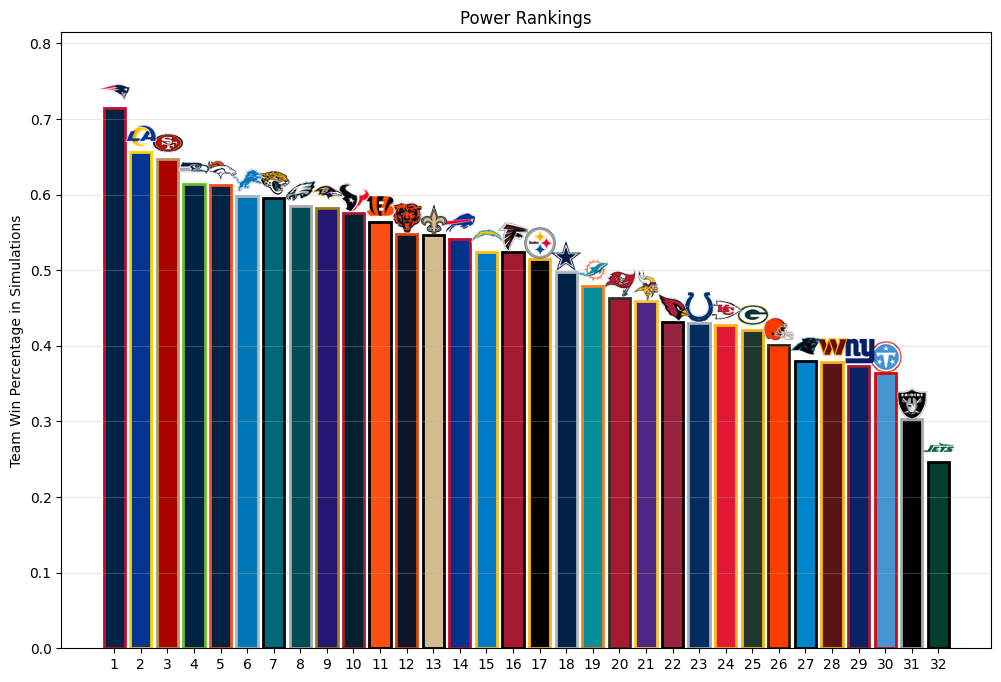

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from PIL import Image
import urllib.request
import numpy as np
import pandas as pd
from io import BytesIO

# Assuming 'rankings' and 'teams' DataFrames are already defined
win_pct_df = pd.DataFrame(rankings)

# Merge win_pct_df with teams DataFrame to get colors and logos
merged_df = pd.merge(win_pct_df, teams, left_on='team', right_on='team_abbr')

# Sort the DataFrame by win_pct in ascending order (highest win_pct on the right)
merged_df = merged_df.sort_values('win_pct')

# Create the figure and axes
fig, ax = plt.subplots(figsize=(12, 8))

# Positions for the bars on the x-axis
x = np.arange(len(merged_df))
x = x[::-1]  # Reverse the x to have highest win_pct on the right

# Plot the bars with team colors and edge colors
bars = ax.bar(
    x,
    merged_df['win_pct'],
    color=merged_df['team_color'],
    edgecolor=merged_df['team_color2'],
    linewidth=2
)

# Label the x-axis with numbers counting up from 1, with 1 on the right
x_labels = np.arange(1, len(merged_df) + 1)
ax.set_xticks(x)
ax.set_xticklabels(x_labels[::-1])

# Add team logos above each bar
for i, bar in enumerate(bars):
    x_value = bar.get_x() + bar.get_width() / 2
    y_value = bar.get_height()
    team = merged_df.iloc[i]['team_abbr']
    logo_url = merged_df.iloc[i]['team_logo_espn']

    # Open the logo image from the URL
    with urllib.request.urlopen(logo_url) as url:
        img = Image.open(url)
        img = img.resize((40, 40), Image.LANCZOS)   # Adjust size as needed
        img = np.array(img)

    # Create an OffsetImage object
    imagebox = OffsetImage(img, zoom=0.6)

    # Adjust the position of the logo
    ab = AnnotationBbox(
        imagebox,
        (x_value, y_value + 0.02),  # Slightly above the bar
        frameon=False,
        xycoords='data'
    )

    # Add the logo to the plot
    ax.add_artist(ab)

# Set labels and title
ax.set_ylabel('Team Win Percentage in Simulations')
ax.set_title(f'Power Rankings')
ax.grid(axis='y', alpha=0.3)

# Optionally adjust y-axis limits to ensure logos fit
ax.set_ylim(0, merged_df['win_pct'].max() + 0.1)

# **Save the figure to a buffer BEFORE showing or closing the figure**
rankings_buf = BytesIO()
fig.savefig(rankings_buf, format='png', bbox_inches='tight')  # Use fig.savefig() here
rankings_buf.seek(0)  # Rewind the buffer to the beginning

# Optionally display the plot (commented out if not needed)
plt.show()

# Close the figure to free memory
plt.close(fig)

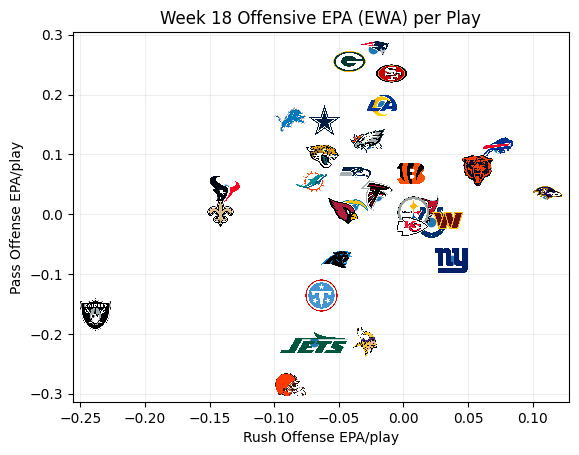

In [ ]:
m = pd.melt(this_week, id_vars=['season', 'week'], value_vars=['home_team', 'away_team'], value_name='team').drop('variable', axis=1).reset_index(drop=True)[['season', 'week', 'team']]
m1 = pd.melt(this_week, id_vars=['season', 'week'], value_vars=['ewma_dynamic_window_rushing_offense_home', 'ewma_dynamic_window_rushing_offense_away'], value_name='ewma_rushing_offense').drop('variable', axis=1).reset_index(drop=True)[['season', 'week', 'ewma_rushing_offense']]
m2 = pd.melt(this_week, id_vars=['season', 'week'], value_vars=['ewma_dynamic_window_passing_offense_home', 'ewma_dynamic_window_passing_offense_away'], value_name='ewma_passing_offense').drop('variable', axis=1).reset_index(drop=True)[['season', 'week', 'ewma_passing_offense']]
combined = pd.concat([m, m1['ewma_rushing_offense'], m2['ewma_passing_offense']], axis=1)

fig, ax = plt.subplots()
ax.scatter(combined['ewma_rushing_offense'], combined['ewma_passing_offense'])

# Add logos to the plot
for x, y, team in zip(combined['ewma_rushing_offense'], combined['ewma_passing_offense'], combined['team']):
    # Read image from URL
    with urllib.request.urlopen(team_logos[team]) as url:
        img = Image.open(url)
        img = np.array(img)

    # Adjust zoom size only for Jets and Packers
    if team in ['NYJ']:  # Adjust based on the correct team abbreviation in your dataset
        zoom_factor = 0.013  # Smaller size for Jets and Packers
    else:
        zoom_factor = 0.05  # Default size for other teams

    # Create offset image with the appropriate zoom
    oi = OffsetImage(img, zoom=zoom_factor)
    # Create annotation box
    ab = AnnotationBbox(oi, (x, y), frameon=False)
    # Add annotation box to the axes
    ax.add_artist(ab)

ax.set_xlabel('Rush Offense EPA/play')
ax.set_ylabel('Pass Offense EPA/play')
ax.set_title(f'Week {current_week} Offensive EPA (EWA) per Play')
ax.grid(alpha=0.2)
#ax.invert_yaxis()

offensive_epa_buf = BytesIO()
fig.savefig(offensive_epa_buf, format='png', bbox_inches='tight')  # Use fig.savefig() here
offensive_epa_buf.seek(0)  # Rewind the buffer to the beginning

# Optionally display the plot (commented out if not needed)
plt.show()

# Close the figure to free memory
plt.close(fig)

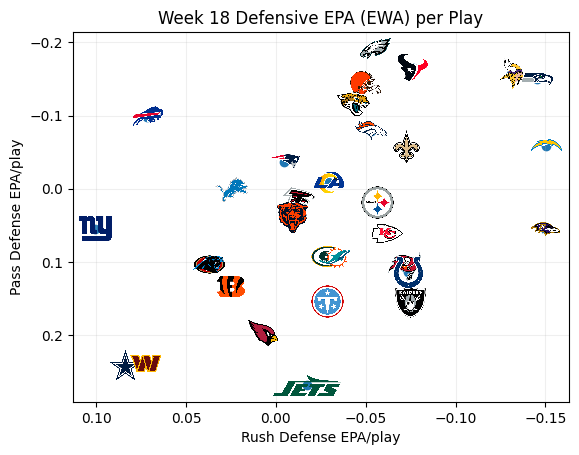

In [ ]:
m = pd.melt(this_week, id_vars=['season', 'week'], value_vars=['home_team', 'away_team'], value_name='team').drop('variable', axis=1).reset_index(drop=True)[['season', 'week', 'team']]
m1 = pd.melt(this_week, id_vars=['season', 'week'], value_vars=['ewma_dynamic_window_rushing_defense_home', 'ewma_dynamic_window_rushing_defense_away'], value_name='ewma_rushing_defense').drop('variable', axis=1).reset_index(drop=True)[['season', 'week', 'ewma_rushing_defense']]
m2 = pd.melt(this_week, id_vars=['season', 'week'], value_vars=['ewma_dynamic_window_passing_defense_home', 'ewma_dynamic_window_passing_defense_away'], value_name='ewma_passing_defense').drop('variable', axis=1).reset_index(drop=True)[['season', 'week', 'ewma_passing_defense']]
combined = pd.concat([m, m1['ewma_rushing_defense'], m2['ewma_passing_defense']], axis=1)
fig, ax = plt.subplots()
ax.scatter(combined['ewma_rushing_defense'], combined['ewma_passing_defense'])

# Add logos to the plot
for x, y, team in zip(combined['ewma_rushing_defense'], combined['ewma_passing_defense'], combined['team']):
    # Read image from URL
    with urllib.request.urlopen(team_logos[team]) as url:
        img = Image.open(url)
        img = np.array(img)

    # Adjust zoom size only for Jets and Packers
    if team in ['NYJ']:  # Adjust based on the correct team abbreviation in your dataset
        zoom_factor = 0.013  # Smaller size for Jets and Packers
    else:
        zoom_factor = 0.05  # Default size for other teams

    # Create offset image with the appropriate zoom
    oi = OffsetImage(img, zoom=zoom_factor)
    # Create annotation box
    ab = AnnotationBbox(oi, (x, y), frameon=False)
    # Add annotation box to the axes
    ax.add_artist(ab)

ax.set_xlabel('Rush Defense EPA/play')
ax.set_ylabel('Pass Defense EPA/play')
ax.set_title(f'Week {current_week} Defensive EPA (EWA) per Play')
ax.grid(alpha=0.2)
ax.invert_yaxis()
ax.invert_xaxis()


defensive_epa_buf = BytesIO()
fig.savefig(defensive_epa_buf, format='png', bbox_inches='tight')  # Use fig.savefig() here
defensive_epa_buf.seek(0)  # Rewind the buffer to the beginning

# Optionally display the plot (commented out if not needed)
plt.show()

# Close the figure to free memory
plt.close(fig)

In [ ]:
# Upload the image to S3
import boto3
s3_client = boto3.client('s3')

def upload_image_to_s3(image_buffer, bucket_name, key):
    s3_client.upload_fileobj(
        image_buffer,
        bucket_name,
        key,
        ExtraArgs={'ContentType': 'image/png', 'CacheControl': 'no-cache'}
    )

upload_image_to_s3(rankings_buf, 'nfl-metrics', 'charts/power_rankings.png')
upload_image_to_s3(offensive_epa_buf, 'nfl-metrics', 'charts/offensive_epa.png')
upload_image_to_s3(defensive_epa_buf, 'nfl-metrics', 'charts/defensive_epa.png')

if feature_importance_buf is not None:
    upload_image_to_s3(feature_importance_buf, 'nfl-metrics', 'charts/feature_importance.png')

# Close the buffers
rankings_buf.close()
offensive_epa_buf.close()
defensive_epa_buf.close()
if feature_importance_buf is not None:
    feature_importance_buf.close()


# Update model record

In [44]:
existing_picks = get_nfl_picks()
historical_results = get_nfl_results()

picks_game_ids = {item['game_id'] for item in existing_picks}
results_game_ids = {item['game_id'] for item in historical_results}

no_results = list(picks_game_ids - results_game_ids)
print(f"Games not in picks that are in results (should be 0): {len(results_game_ids - picks_game_ids)}")
print(f"{len(no_results)} picks need to be updated")


Games not in picks that are in results (should be 0): 0
0 picks need to be updated


In [45]:
picks_to_update = pd.DataFrame([item for item in existing_picks if item["game_id"] in no_results])

scores = {
    row["game_id"]: {
        "home_score": row["home_score"],
        "away_score": row["away_score"],
    }
    for _, row in df[["game_id", "home_score", "away_score"]].iterrows()
    if pd.notna(row["home_score"]) and pd.notna(row["away_score"])
}

if picks_to_update.empty:
    print("No picks need results updates.")
else:
    picks_to_update = picks_to_update[picks_to_update["game_id"].isin(scores.keys())].copy()

    if picks_to_update.empty:
        print("No completed games need results updates.")
    else:
        picks_to_update["home_score"] = picks_to_update["game_id"].apply(
            lambda game_id: scores[game_id]["home_score"]
        )
        picks_to_update["away_score"] = picks_to_update["game_id"].apply(
            lambda game_id: scores[game_id]["away_score"]
        )

        picks_to_update = calculate_wins(picks_to_update)
        check = get_result_stats(picks_to_update, Verbose=True)

        print(f"Updating {len(picks_to_update)} picks")


No picks need results updates.


In [46]:
if picks_to_update.empty:
    print("Nothing to preview for results updates.")
else:
    print(len(picks_to_update[[
        'season', 'week', 'home_team', 'away_team', 'home_score', 'away_score',
        'home_score_pred', 'away_score_pred', 'spread_pred', 'spread_line',
        'true_spread', 'spread_play', 'spread_win_prob', 'spread_lock',
        'correct_spread_play', 'spread_win', 'total_pred', 'total_line',
        'true_total', 'total_play', 'total_win_prob', 'total_lock',
        'correct_total_play', 'total_win', 'year_week', 'game_id', 'date_time'
    ]]))

    picks_to_update[[
        'home_team', 'away_team', 'home_score', 'away_score',
        'home_score_pred', 'away_score_pred', 'spread_pred', 'spread_line',
        'true_spread', 'spread_play', 'spread_lock', 'correct_spread_play',
        'spread_win', 'total_pred', 'total_line', 'true_total', 'total_play',
        'total_lock', 'correct_total_play', 'total_win'
    ]]


Nothing to preview for results updates.


In [47]:
if picks_to_update.empty:
    print("Skipping results write: no rows to update.")
else:
    write_postgres_results(picks_to_update)
    print(f"Wrote {len(picks_to_update)} result rows.")

Skipping results write: no rows to update.


In [ ]:
sys.exit(0)

# Results

In [48]:
results_df = pd.DataFrame(get_nfl_results())
results_df = pd.DataFrame(get_nfl_results())

In [49]:
#esults_df=results_df[results_df['week']=='6']
catch = get_result_stats(results_df, Verbose = True)

Spread Win Percentage: 48.06%
Total Win Percentage: 51.10%

Spread Lock Win Percentage: 49.67%
Total Lock Win Percentage: 49.69%


# Scratch 

In [162]:
# Results

In [ ]:
def season_stats(df, current_week, year, score_pipeline):
    season_results = {}
    results_list = []
    for i in range(1,current_week+1):

        train_df = df[((df['season'] == year) & (df['week'] < i)) | (df['season'] < year)]
        train_df = train_df.dropna(subset = 'home_score', inplace=False)

        X = train_df[input_features]
        y = train_df[targets]   

        #do and eval split to fit classifiers
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
        eval_results  = fit_eval(train_df, X_train, X_test, y_train, y_test, score_pipeline)
        spread_clf_temp, total_clf_temp = fit_classifiers(eval_results, spread_class_features, total_class_features)

        score_model_temp =  fit_score_model(X, y, score_pipeline)

        #predict this week
        test_df = df[(df['season'] == year) & (df['week'] == i)]
        X_test = test_df.loc[:, features]

        away_scores = score_model_temp.predict_scores(X_test[features], 'away')
        home_scores = score_model_temp.predict_scores(X_test[features], 'home')
        test_df['away_score_pred'] = away_scores
        test_df['home_score_pred'] = home_scores

        plays = scores_to_bets(test_df)
        plays['spread_win_prob'] = win_probability(plays, classifier = spread_clf, features = spread_class_features)
        plays['total_win_prob'] = win_probability(plays, classifier = total_clf, features = total_class_features)
        plays = determine_plays(plays)


        #get results
        results = calculate_wins(plays)
        data = get_result_stats(results, Verbose = False)

        

        season_results[i] = data
        season_results[i]['df'] = results

        results_list.append(results)
        
        print(f"Week {i} done")
        
    combined_results = pd.concat(results_list, ignore_index=True)    
    return season_results, combined_results

Week 1 done
Week 2 done
Week 3 done
Week 4 done
Week 5 done
Week 6 done
Week 7 done
Week 8 done
Week 9 done
Week 10 done
Week 11 done
Week 12 done
Week 13 done
Week 14 done
Week 15 done
Week 16 done
Week 17 done
Week 18 done
Season spread win percentage: 48.53%
Season total win percentage: 53.31%

Season spread lock win percentage: 52.05%
Season total lock win percentage: 54.55%


In [ ]:
season_results,season_results_df = season_stats(df, current_week = 18, year = 2023, score_pipeline=score_pipeline)

total_spread_wins = sum(val['spread_wins'] for val in season_results.values())
total_total_wins = sum(val['total_wins'] for val in season_results.values())
total_games = sum(val['predicted_games'] for val in season_results.values())

total_spread_ratio = 100 * total_spread_wins / total_games
total_total_ratio = 100 * total_total_wins / total_games

total_spread_lock_wins = sum(val['spread_lock_wins'] for val in season_results.values())
total_total_lock_wins = sum(val['total_lock_wins'] for val in season_results.values())
total_spread_lock_games = sum(val['spread_lock_predictions'] for val in season_results.values())
total_total_lock_games = sum(val['total_lock_predictions'] for val in season_results.values())


total_spread_lock_ratio = 100* total_spread_lock_wins / total_spread_lock_games 
total_total_lock_ratio = 100 * total_total_lock_wins / total_total_lock_games

print(f"Season spread win percentage: {total_spread_ratio:.2f}%")
print(f"Season total win percentage: {total_total_ratio:.2f}%\n")
print(f"Season spread lock win percentage: {total_spread_lock_ratio:.2f}%")
print(f"Season total lock win percentage: {total_total_lock_ratio:.2f}%")

,season,week,home_team,away_team,home_score_pred,home_score,spread_pred,spread_line,true_spread,spread_play,spread_win_prob,correct_spread_play,spread_win,total_pred,total_line,true_total,total_play,total_win_prob,correct_total_play,total_win
3842,2024,4,NYG,DAL,16.703344,15.0,-8.693796,-5.5,-5.0,DAL,45.600235,NYG,0,42.100485,45.0,35.0,under,58.868575,under,1
3843,2024,4,ATL,NO,22.848740,26.0,-2.535837,2.5,2.0,NO,54.416106,NO,1,48.233317,41.5,50.0,over,70.762942,over,1
3844,2024,4,CAR,CIN,23.333920,24.0,-6.556497,-4.5,-10.0,CIN,57.167352,CIN,1,53.224338,47.0,58.0,over,82.164559,over,1
3845,2024,4,CHI,LA,22.029294,24.0,1.401981,3.0,6.0,LA,54.019234,CHI,0,42.656608,40.0,42.0,over,70.451877,over,1
3846,2024,4,GB,MIN,22.140346,29.0,3.502799,2.5,-2.0,GB,47.330288,MIN,0,40.777893,44.0,60.0,under,51.475143,over,0
3847,2024,4,HOU,JAX,32.486968,24.0,14.257919,5.5,4.0,HOU,70.599947,JAX,0,50.716016,44.5,44.0,over,65.536666,under,0
3848,2024,4,IND,PIT,20.448996,27.0,-0.664179,-2.5,3.0,IND,39.754149,IND,1,41.562171,40.0,51.0,over,40.380344,over,1
3849,2024,4,NYJ,DEN,23.941120,9.0,6.270982,7.5,-1.0,DEN,55.636431,DEN,1,41.611259,39.5,19.0,over,74.281007,under,0
3850,2024,4,TB,PHI,19.532987,33.0,-2.563405,-1.0,17.0,PHI,63.511029,TB,0,41.629379,42.0,49.0,under,41.760528,over,0
3851,2024,4,ARI,WAS,29.463173,14.0,6.123964,3.5,-28.0,ARI,52.395994,WAS,0,52.802383,49.0,56.0,over,51.963119,over,1


In [ ]:
season_results[4]['df'][['season', 'week', 'home_team', 'away_team', 'home_score_pred', 'home_score',
          'spread_pred', 'spread_line', 'true_spread', 'spread_play', 'spread_win_prob' , 'correct_spread_play', 'spread_win',
          'total_pred', 'total_line', 'true_total', 'total_play', 'total_win_prob', 'correct_total_play', 'total_win']]

# Supplemental Analytics

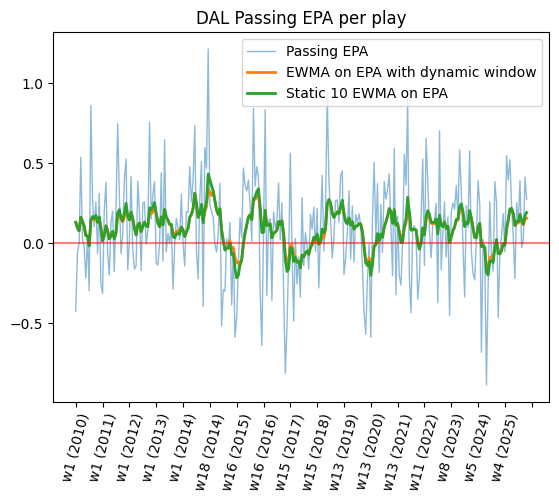

In [32]:
if client_name == 'notebook':
    team = 'DAL'
    tm = epa.loc[epa['team'] == team, :].assign(
        season_week = lambda x: 'w' + x.week.astype(str) + ' (' + x.season.astype(str) + ')'
    ).set_index('season_week')

    fig, ax = plt.subplots()

    loc = plticker.MultipleLocator(base=16) # this locator puts ticks at regular intervals
    ax.xaxis.set_major_locator(loc)
    ax.tick_params(axis='x', rotation=75) #rotate the x-axis labels a bit

    ax.plot(tm['epa_shifted_passing_offense'], lw=1, alpha=0.5)
    ax.plot(tm['ewma_dynamic_window_passing_offense'], lw=2)
    ax.plot(tm['ewma_passing_offense'], lw=2)
    plt.axhline(y=0, color='red', lw=1.5, alpha=0.5)

    ax.legend(['Passing EPA', 'EWMA on EPA with dynamic window', 'Static 10 EWMA on EPA'])
    ax.set_title(f'{team} Passing EPA per play')
    plt.show()

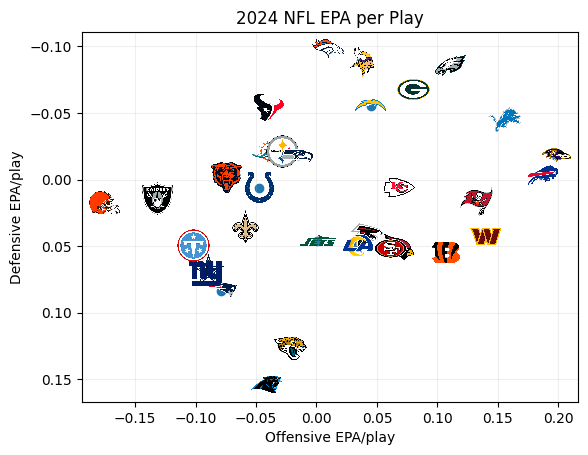

In [33]:
if client_name == 'notebook':
    import matplotlib.pyplot as plt
    import matplotlib.image as mpimg
    from matplotlib.offsetbox import OffsetImage, AnnotationBbox
    from PIL import Image
    import urllib.request
    import numpy as np


    # Assuming nflreadr::load_pbp(2020) loads a pandas DataFrame
    pbp_viz = pbp[(pbp['season'] == 2024) & (pbp['season_type'] == 'REG') & (pbp['posteam'].notna()) & ((pbp['rush'] == 1) | (pbp['pass'] == 1))] #(pbp['rz'] == 1) &

    offense = pbp_viz.groupby('posteam').agg({'epa': np.mean}).reset_index().rename(columns={'posteam': 'team', 'epa': 'off_epa'})
    pass_offense = pbp_viz[pbp_viz['pass_attempt']==1].groupby('posteam').agg({'epa': np.mean}).reset_index().rename(columns={'posteam': 'team', 'epa': 'off_pass_epa'})
    run_offense = pbp_viz[pbp_viz['rush_attempt']==1].groupby('posteam').agg({'epa': np.mean}).reset_index().rename(columns={'posteam': 'team', 'epa': 'off_run_epa'})
    rz_offense =pbp_viz[pbp_viz['rz']==1].groupby('posteam').agg({'epa': np.mean}).reset_index().rename(columns={'posteam': 'team', 'epa': 'rz_off_epa'})
    non_rz_offense=pbp_viz[pbp_viz['rz']==0].groupby('posteam').agg({'epa': np.mean}).reset_index().rename(columns={'posteam': 'team', 'epa': 'non_rz_off_epa'})



    defense = pbp_viz.groupby('defteam').agg({'epa': np.mean}).reset_index().rename(columns={'defteam': 'team', 'epa': 'def_epa'})

    combined = pd.merge(offense, defense, on='team')

    qbs = pbp_viz[(pbp_viz['pass'] == 1) | (pbp_viz['rush'] == 1) & pbp_viz['down'].isin(range(1, 5))].groupby('id').agg({
        'name': 'first',
        'posteam': 'last',
        'id': 'count',
        'qb_epa': np.mean
    }).rename(columns={'id': 'plays', 'posteam': 'team'}).query('plays > 200').nlargest(10, 'qb_epa')

    # Assuming that 'team_logos' is a dictionary with team names as keys and URLs/paths of logos as values
    team_logos = teams.set_index('team_abbr')['team_logo_espn'].to_dict()

    fig, ax = plt.subplots()
    ax.scatter(combined['off_epa'], combined['def_epa'])

    for x, y, team in zip(combined['off_epa'], combined['def_epa'], combined['team']):

        with urllib.request.urlopen(team_logos[team]) as url:
            img = Image.open(url)
            img = np.array(img)
        
        # Adjust zoom size only for Jets and Packers
        if team in ['NYJ']:  # Adjust based on the correct team abbreviation in your dataset
            zoom_factor = 0.007  # Smaller size for Jets and Packers
        else:
            zoom_factor = 0.05  # Default size for other teams
        
        # Create offset image with the appropriate zoom
        oi = OffsetImage(img, zoom=zoom_factor)
        # Create annotation box
        ab = AnnotationBbox(oi, (x, y), frameon=False)
        # Add annotation box to the axes
        ax.add_artist(ab)
        
    ax.set_xlabel('Offensive EPA/play')
    ax.set_ylabel('Defensive EPA/play')
    ax.set_title('2024 NFL EPA per Play')
    ax.grid(alpha=0.2)
    ax.invert_yaxis()
    plt.show()

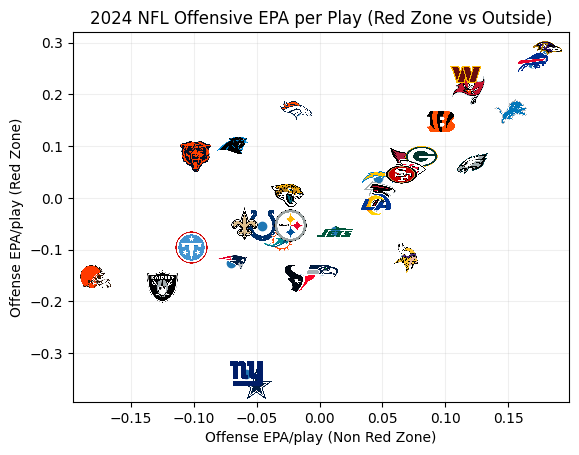

In [35]:
if client_name == 'notebook':

    import matplotlib.pyplot as plt
    import matplotlib.image as mpimg
    from matplotlib.offsetbox import OffsetImage, AnnotationBbox
    from PIL import Image
    import urllib.request
    import numpy as np


    # Assuming nflreadr::load_pbp(2020) loads a pandas DataFrame
    pbp_viz = pbp[(pbp['season'] == 2024) & (pbp['season_type'] == 'REG') & (pbp['posteam'].notna()) & ((pbp['rush'] == 1) | (pbp['pass'] == 1))] #(pbp['rz'] == 1) &

    offense = pbp_viz.groupby('posteam').agg({'epa': np.mean}).reset_index().rename(columns={'posteam': 'team', 'epa': 'off_epa'})
    pass_offense = pbp_viz[pbp_viz['pass_attempt']==1].groupby('posteam').agg({'epa': np.mean}).reset_index().rename(columns={'posteam': 'team', 'epa': 'off_pass_epa'})
    run_offense = pbp_viz[pbp_viz['rush_attempt']==1].groupby('posteam').agg({'epa': np.mean}).reset_index().rename(columns={'posteam': 'team', 'epa': 'off_run_epa'})
    rz_offense =pbp_viz[pbp_viz['rz']==1].groupby('posteam').agg({'epa': np.mean}).reset_index().rename(columns={'posteam': 'team', 'epa': 'rz_off_epa'})
    non_rz_offense=pbp_viz[pbp_viz['rz']==0].groupby('posteam').agg({'epa': np.mean}).reset_index().rename(columns={'posteam': 'team', 'epa': 'non_rz_off_epa'})



    defense = pbp_viz.groupby('defteam').agg({'epa': np.mean}).reset_index().rename(columns={'defteam': 'team', 'epa': 'def_epa'})

    combined = pd.merge(rz_offense, non_rz_offense, on='team')

    qbs = pbp_viz[(pbp_viz['pass'] == 1) | (pbp_viz['rush'] == 1) & pbp_viz['down'].isin(range(1, 5))].groupby('id').agg({
        'name': 'first',
        'posteam': 'last',
        'id': 'count',
        'qb_epa': np.mean
    }).rename(columns={'id': 'plays', 'posteam': 'team'}).query('plays > 200').nlargest(10, 'qb_epa')

    # Assuming that 'team_logos' is a dictionary with team names as keys and URLs/paths of logos as values
    team_logos = teams.set_index('team_abbr')['team_logo_espn'].to_dict()

    fig, ax = plt.subplots()
    ax.scatter(combined['non_rz_off_epa'], combined['rz_off_epa'])

    # Add logos to the plot
    for x, y, team in zip(combined['non_rz_off_epa'], combined['rz_off_epa'], combined['team']):
        # Read image from URL
        with urllib.request.urlopen(team_logos[team]) as url:
            img = Image.open(url)
            img = np.array(img)
        # Adjust zoom size only for Jets and Packers
        if team in ['NYJ']:  # Adjust based on the correct team abbreviation in your dataset
            zoom_factor = 0.007  # Smaller size for Jets and Packers
        else:
            zoom_factor = 0.05  # Default size for other teams
        oi = OffsetImage(img, zoom=zoom_factor)
        # Create annotation box
        ab = AnnotationBbox(oi, (x, y), frameon=False)
        # Add annotation box to the axes
        ax.add_artist(ab)
        
    ax.set_xlabel('Offense EPA/play (Non Red Zone)')
    ax.set_ylabel('Offense EPA/play (Red Zone)')
    ax.set_title('2024 NFL Offensive EPA per Play (Red Zone vs Outside)')
    ax.grid(alpha=0.2)
    #ax.invert_yaxis()
    plt.show()